# Notebook 04: Prediction Debiasing — DR 메커니즘 + Ablation Study

**목표:**
1. DR (Doubly Robust) debiasing이 calibration을 달성하는 **이론적 메커니즘** 설명
2. Component-level ablation: CFR lambda, External PS, ESMM vs DR
3. AUC vs Calibration trade-off 심층 분석
4. Phase 7-18 실험에서 얻은 negative results 정리

**Cross-reference:** Notebook 03은 8개 모델의 통합 비교를 제공. 본 노트북은 **왜** ESCM2-WC(DR)이 IEB 0.014의 near-perfect calibration을 달성하는지 분석한다.

In [1]:
# Path configuration
import sys
from pathlib import Path

# Project root (1 level up from notebook)
PROJECT_ROOT = Path('.').absolute().parent
sys.path.insert(0, str(PROJECT_ROOT))

# Results paths
RESULTS_PATH = PROJECT_ROOT / 'results'
FIG_PATH = RESULTS_PATH / 'figures'
MODEL_PATH = RESULTS_PATH / 'models'

# Create directories if needed
FIG_PATH.mkdir(parents=True, exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'RESULTS_PATH: {RESULTS_PATH}')

PROJECT_ROOT: /Users/taehyun/project/rtb_ipinyou
RESULTS_PATH: /Users/taehyun/project/rtb_ipinyou/results


In [2]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.metrics import (
    load_neural_result, normalize_to_unified,
    build_comparison_table, highlight_best,
)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

SEED = 42
np.random.seed(SEED)

print('Libraries loaded successfully.')

Libraries loaded successfully.


---
## Section 1: DR Debiasing 이론

### 1.1 Selection Bias 문제 정의

RTB에서 CTR 예측의 근본 문제: **Win Selection Bias**.

- 우리가 원하는 것: $E[\text{click} | X]$ — 모든 bid에 대한 CTR
- 우리가 관측하는 것: click은 **win한 경우에만** 관측
- Naive 추정: $E_{\text{naive}}[y|X] = E[y|X, \text{Win}=1] \neq E[y|X]$

Win 확률이 X와 상관되면 (e.g., 높은 bid → 높은 win → 다른 CTR 분포), naive estimator는 **체계적으로 편향**된다.

### 1.2 IPW (Inverse Propensity Weighting) Estimator

$$\mathcal{L}_{\text{IPW}} = \frac{1}{n} \sum_{i=1}^{n} \frac{\text{win}_i}{P(\text{Win}|X_i)} \cdot L(p_{\text{ctr}}(X_i), \text{click}_i)$$

- **장점**: Selection bias 해소 (unbiased if $P(\text{Win}|X)$ is correct)
- **단점**: High variance when $P(\text{Win}|X) \approx 0$ (positivity violation)

### 1.3 DR (Doubly Robust) Estimator

$$\mathcal{L}_{\text{DR}} = \frac{1}{n} \sum_{i=1}^{n} \left[ \hat{\delta}(X_i) + \frac{\text{win}_i}{P(\text{Win}|X_i)} \cdot \left( \epsilon_i - \hat{\delta}(X_i) \right) \right]^2$$

여기서 $\epsilon_i = \text{click}_i - p_{\text{ctr}}(X_i)$, $\hat{\delta}$는 imputation tower의 prediction.

**Double Robustness Property**: 다음 중 **하나만** 올바르면 consistent:
1. $P(\text{Win}|X)$ (propensity model) — Win tower
2. $\hat{\delta}(X)$ (imputation model) — Imputation tower

### 1.4 왜 IEB가 개선되는가?

DR loss로 학습된 CTR tower는 $E[p_{\text{CTR}}(X)] \approx E[\text{click}|X]$ (전체 모집단 대상).
WCTR = $p_{\text{Win}} \times p_{\text{CTR}}$이므로:

$$E[\text{WCTR}] = E[p_{\text{Win}} \cdot p_{\text{CTR}}] \approx E[\text{click}_{\text{bid}}]$$

이것이 IEB (= $|E[\text{pred}] - E[\text{actual}]| / E[\text{actual}]$)를 0에 가깝게 만든다.

### 1.5 CFR (Counterfactual Risk) Regularization

$$\mathcal{L}_{\text{CFR}} = \frac{1}{n_{\text{unwin}}} \sum_{\text{win}=0} \hat{\delta}(X_i)^2$$

Win=0인 샘플에서 imputation prediction을 0으로 regularize — "관측 불가 영역에서 보수적 추정".
과도한 CFR(>0.2)은 $\hat{\delta} \approx 0$으로 수렴시켜 순수 IPW로 퇴화 → positivity 위반 노출.

### Architecture: ESMM-WC (2-tower) vs ESCM2-WC (3-tower)

```
ESMM-WC (2-tower)                    ESCM2-WC (3-tower)
==================                    ==================

  Input X (bid features)                Input X (bid features)
       |                                     |
  [Shared Embedding]                    [Shared Embedding]
       |                                     |
  +---------+                     +----------+----------+
  |         |                     |          |          |
[Win MLP] [CTR MLP]           [Win MLP] [CTR MLP] [Impute MLP]
  |         |                     |          |          |
 p_win    p_ctr                 p_win      p_ctr     delta_hat
  |         |                     |          |          |
  +-- WCTR -+                     |    DR correction   |
  p_win*p_ctr                     |  delta_hat +       |
                                  |  (win/p_win)*      |
                                  |  (error-delta_hat) |
                                  |          |          |
                                  +-- WCTR --+          |
                                  p_win*p_ctr           |
```

| Component | ESMM-WC | ESCM2-WC(DR) |
|-----------|---------|-------------|
| Win Tower | BCE loss (win label) | BCE loss (win label) |
| CTR Tower | BCE loss (click, won-only) | **DR loss** (click, all bids via IPW+imputation) |
| Imputation Tower | — | MSE on won samples: $\hat{\delta} \approx \text{click} - p_{\text{ctr}}$ |
| Joint Constraint | $\text{WCTR} = p_{\text{win}} \times p_{\text{ctr}}$ → BCE | Same |
| CFR Regularization | — | $\lambda \cdot E_{\text{win}=0}[\hat{\delta}^2]$ |

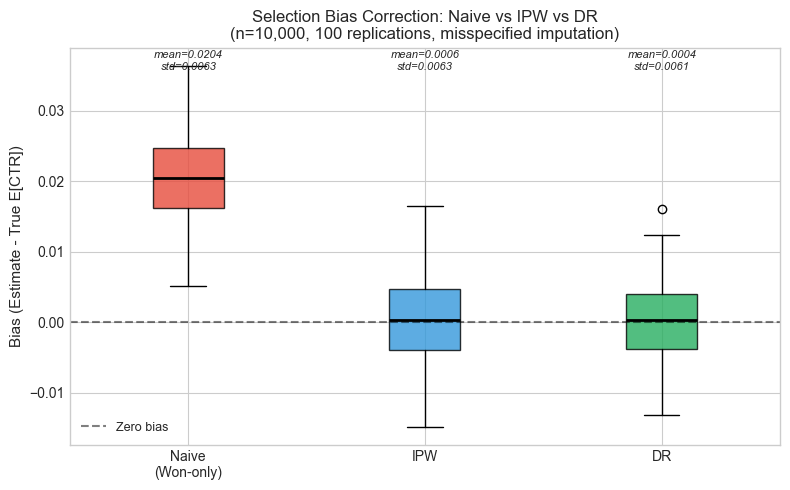

True E[CTR(X)]: 0.2491
Naive mean bias: 0.0204 (systematic upward bias)
IPW   mean bias: 0.0006 (unbiased, high variance)
DR    mean bias: 0.0004 (unbiased, lower variance)


In [3]:
# Toy Simulation: DR Unbiasedness Demonstration
# Synthetic bid-win-click data, 100 replications

rng = np.random.default_rng(42)
n_samples = 10_000
n_reps = 100

# True functions (fixed across replications)
x = rng.uniform(0, 1, n_samples)
true_ctr = 0.1 + 0.3 * x         # CTR increases with x
true_win_prob = 0.3 + 0.4 * x     # Win prob also increases → selection bias
true_mean_ctr = true_ctr.mean()   # Population E[CTR(X)]

# Misspecified imputation model (deliberately biased)
delta_hat_model = 0.08 + 0.15 * x  # Wrong slope, wrong intercept

estimator_names = ['Naive\n(Won-only)', 'IPW', 'DR']
biases = {name: [] for name in estimator_names}

for _ in range(n_reps):
    win = rng.binomial(1, true_win_prob)
    click = win * rng.binomial(1, true_ctr)

    # Naive: E[click | win=1]
    naive_est = click[win == 1].mean() if win.sum() > 0 else 0.0
    biases[estimator_names[0]].append(naive_est - true_mean_ctr)

    # IPW: (1/n) * sum(win/P(win) * click)
    ipw_est = (win / true_win_prob * click).mean()
    biases[estimator_names[1]].append(ipw_est - true_mean_ctr)

    # DR: (1/n) * sum(delta_hat + win/P(win) * (click - delta_hat))
    dr_est = (delta_hat_model + win / true_win_prob * (click - delta_hat_model)).mean()
    biases[estimator_names[2]].append(dr_est - true_mean_ctr)

# Boxplot of bias distributions
fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    [biases[n] for n in estimator_names],
    labels=estimator_names, patch_artist=True,
    boxprops=dict(alpha=0.8), medianprops=dict(color='black', linewidth=2),
)
colors = ['#e74c3c', '#3498db', '#27ae60']
list(map(lambda pair: pair[0].set_facecolor(pair[1]), zip(bp['boxes'], colors)))

ax.axhline(y=0, color='black', linestyle='--', alpha=0.5, label='Zero bias')
ax.set_ylabel('Bias (Estimate - True E[CTR])', fontsize=11)
ax.set_title('Selection Bias Correction: Naive vs IPW vs DR\n'
             f'(n={n_samples:,}, {n_reps} replications, misspecified imputation)',
             fontsize=12)
ax.legend(fontsize=9)

# Annotate mean bias
for i, name in enumerate(estimator_names):
    mean_bias = np.mean(biases[name])
    std_bias = np.std(biases[name])
    ax.text(i + 1, ax.get_ylim()[1] * 0.92,
            f'mean={mean_bias:.4f}\nstd={std_bias:.4f}',
            ha='center', fontsize=8, style='italic')

plt.tight_layout()
plt.savefig(FIG_PATH / '04_dr_unbiasedness_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'True E[CTR(X)]: {true_mean_ctr:.4f}')
print(f'Naive mean bias: {np.mean(biases[estimator_names[0]]):.4f} (systematic upward bias)')
print(f'IPW   mean bias: {np.mean(biases[estimator_names[1]]):.4f} (unbiased, high variance)')
print(f'DR    mean bias: {np.mean(biases[estimator_names[2]]):.4f} (unbiased, lower variance)')

---
## Section 2: 실험 결과 로딩

In [4]:
# --- JSON result files (6 files) ---
json_runs = {
    'J':  MODEL_PATH / 'esmmwc_lw_j' / 'esmmwc_result.json',
    'AK': MODEL_PATH / 'escm2wc_dr_result_AK.json',
    'AJ': MODEL_PATH / 'escm2wc_dr_result_AJ.json',
    'AL': MODEL_PATH / 'escm2wc_dr_result_AL.json',
    'AM': MODEL_PATH / 'escm2wc_dr_result_AM.json',
    'AP': MODEL_PATH / 'escm2wc_dr_result_AP.json',
}

results = {}
for run_id, path in json_runs.items():
    if path.exists():
        results[run_id] = load_neural_result(path)
        print(f'  Run {run_id}: loaded ({results[run_id].get("model_name", "?")})')
    else:
        print(f'  Run {run_id}: NOT FOUND at {path}')

# --- Hardcoded results (no JSON, from docs/performance_tuning.md) ---
hardcoded = {
    'R':  dict(run='R',  model='ESCM2-WC(DR)',  cfr=0.1, note='MSE, ctr_w=0.01',
              wctr_auc=0.6766, wctr_ieb=0.056, ctr_auc=0.5526, win_auc=0.6389),
    'P':  dict(run='P',  model='ESCM2-WC(DR)',  cfr=0.1, note='ctr_w=0.0',
              wctr_auc=0.6728, wctr_ieb=0.057, ctr_auc=0.5534, win_auc=0.6389),
    'Q':  dict(run='Q',  model='ESCM2-WC(IPW)', cfr=0.0, note='IPW debiasing',
              wctr_auc=0.6526, wctr_ieb=0.046, ctr_auc=0.5292, win_auc=0.6347),
    'AW': dict(run='AW', model='ESCM2-WC(DR)',  cfr=0.2, note='AL + External PS',
              wctr_auc=0.6882, wctr_ieb=0.045, ctr_auc=0.5713, win_auc=0.6466),
    'AV': dict(run='AV', model='ESCM2-WC(DR)',  cfr=0.1, note='J cfg + External PS',
              wctr_auc=0.6712, wctr_ieb=0.035, ctr_auc=0.5604, win_auc=0.6384),
    'AQ': dict(run='AQ', model='ESCM2-WC(DR)',  cfr=0.3, note='cfr_lambda=0.3',
              wctr_auc=0.6841, wctr_ieb=0.114, ctr_auc=0.5407, win_auc=None),
    'AR': dict(run='AR', model='ESCM2-WC(DR)',  cfr=0.5, note='cfr_lambda=0.5',
              wctr_auc=0.6774, wctr_ieb=0.105, ctr_auc=0.5489, win_auc=None),
}

# --- Build unified summary DataFrame ---
summary_rows = []

# From JSON
json_meta = {
    'J':  ('ESMM-WC',       'none', None),
    'AK': ('ESCM2-WC(DR)',  'DR',   0.0),
    'AJ': ('ESCM2-WC(DR)',  'DR',   0.1),
    'AL': ('ESCM2-WC(DR)',  'DR',   0.2),
    'AM': ('ESCM2-WC(DR)',  'DR',   0.1),
    'AP': ('ESCM2-WC(DR)',  'DR',   0.2),
}
for run_id, r in results.items():
    model_label, debiasing, cfr = json_meta[run_id]
    summary_rows.append(dict(
        Run=run_id, Model=model_label, Debiasing=debiasing,
        cfr_lambda=cfr,
        WCTR_AUC=r.get('test_wctr_auc', 0),
        WCTR_IEB=r.get('test_wctr_ieb', 0),
        CTR_AUC=r.get('test_ctr_biased_auc', 0),
        Win_AUC=r.get('test_win_auc', 0),
        Source='JSON',
        Note=json_meta[run_id][1],
    ))

# From hardcoded
for run_id, h in hardcoded.items():
    summary_rows.append(dict(
        Run=run_id, Model=h['model'], Debiasing='DR' if 'DR' in h['model'] else 'IPW',
        cfr_lambda=h['cfr'],
        WCTR_AUC=h['wctr_auc'],
        WCTR_IEB=h['wctr_ieb'],
        CTR_AUC=h['ctr_auc'],
        Win_AUC=h.get('win_auc'),
        Source='Hardcoded',
        Note=h['note'],
    ))

df_summary = pd.DataFrame(summary_rows)
print(f'Total runs loaded: {len(df_summary)} ({len(results)} JSON + {len(hardcoded)} hardcoded)')
display(df_summary.style.format({
    'WCTR_AUC': '{:.4f}', 'WCTR_IEB': '{:.3f}',
    'CTR_AUC': '{:.4f}', 'Win_AUC': lambda x: f'{x:.4f}' if x is not None else '—',
    'cfr_lambda': lambda x: f'{x:.1f}' if x is not None else '—',
}))

  Run J: loaded (esmmwc)
  Run AK: loaded (escm2wc_dr)
  Run AJ: loaded (escm2wc_dr)
  Run AL: loaded (escm2wc_dr)
  Run AM: loaded (escm2wc_dr)
  Run AP: loaded (escm2wc_dr)
Total runs loaded: 13 (6 JSON + 7 hardcoded)


,Run,Model,Debiasing,cfr_lambda,WCTR_AUC,WCTR_IEB,CTR_AUC,Win_AUC,Source,Note
0,J,ESMM-WC,none,nan,0.6905,1.335,0.6237,0.6432,JSON,none
1,AK,ESCM2-WC(DR),DR,0.0,0.6638,0.053,0.5338,0.6379,JSON,DR
2,AJ,ESCM2-WC(DR),DR,0.1,0.6664,0.122,0.5335,0.6377,JSON,DR
3,AL,ESCM2-WC(DR),DR,0.2,0.6843,0.014,0.5636,0.6403,JSON,DR
4,AM,ESCM2-WC(DR),DR,0.1,0.6377,0.268,0.4458,0.6504,JSON,DR
5,AP,ESCM2-WC(DR),DR,0.2,0.6722,0.131,0.5377,0.6429,JSON,DR
6,R,ESCM2-WC(DR),DR,0.1,0.6766,0.056,0.5526,0.6389,Hardcoded,"MSE, ctr_w=0.01"
7,P,ESCM2-WC(DR),DR,0.1,0.6728,0.057,0.5534,0.6389,Hardcoded,ctr_w=0.0
8,Q,ESCM2-WC(IPW),IPW,0.0,0.6526,0.046,0.5292,0.6347,Hardcoded,IPW debiasing
9,AW,ESCM2-WC(DR),DR,0.2,0.6882,0.045,0.5713,0.6466,Hardcoded,AL + External PS


---
## Section 3: ESMM-WC vs ESCM2-WC(DR) 구조적 비교

Run J (ESMM-WC) vs Run AL (ESCM2-WC DR, cfr=0.2) — **동일 HP에서 구조 차이만의 효과.**

두 모델은 동일한 shared embedding (dim=32), hidden_dims=[128,64], dropout=0.4,
lr=5e-4, cosine scheduler, win_weight=0.01을 사용.
차이점: AL은 3rd imputation tower + DR loss + CFR regularization 추가.

In [5]:
# Side-by-side comparison: Run J (ESMM-WC) vs Run AL (ESCM2-WC DR)
if 'J' in results and 'AL' in results:
    # Won-only context
    won_metrics = [
        normalize_to_unified(results['J'], 'won_only'),
        normalize_to_unified(results['AL'], 'won_only'),
    ]
    print('=== Won-Only CTR (biased) Comparison ===')
    df_won = build_comparison_table(won_metrics)
    display(highlight_best(df_won))

    # All-bids context
    all_metrics = [
        normalize_to_unified(results['J'], 'all_bids'),
        normalize_to_unified(results['AL'], 'all_bids'),
    ]
    print('\n=== All-Bids WCTR Comparison ===')
    df_all = build_comparison_table(all_metrics)
    display(highlight_best(df_all))

    # Key deltas
    j, al = results['J'], results['AL']
    print('\n--- Key Deltas (AL - J) ---')
    print(f'  WCTR AUC:  {al["test_wctr_auc"] - j["test_wctr_auc"]:+.4f}  '
          f'(J {j["test_wctr_auc"]:.4f} vs AL {al["test_wctr_auc"]:.4f})')
    print(f'  WCTR IEB:  {al["test_wctr_ieb"] - j["test_wctr_ieb"]:+.4f}  '
          f'(J {j["test_wctr_ieb"]:.3f} vs AL {al["test_wctr_ieb"]:.3f})')
    print(f'  CTR AUC:   {al["test_ctr_biased_auc"] - j["test_ctr_biased_auc"]:+.4f}  '
          f'(J {j["test_ctr_biased_auc"]:.4f} vs AL {al["test_ctr_biased_auc"]:.4f})')
    print(f'  Win AUC:   {al["test_win_auc"] - j["test_win_auc"]:+.4f}  '
          f'(J {j["test_win_auc"]:.4f} vs AL {al["test_win_auc"]:.4f})')
else:
    print('Run J or AL not loaded. Skipping structural comparison.')

=== Won-Only CTR (biased) Comparison ===


,Model,Type,Context,AUC,Log Loss,ECE,IEB
0,esmmwc CTR (biased),esmmwc,won_only,0.6237,—,5.67e-06,0.0054
1,escm2wc_dr CTR (biased),escm2wc_dr,won_only,0.5636,—,5.45e-04,0.5153



=== All-Bids WCTR Comparison ===


,Model,Type,Context,AUC,Log Loss,ECE,IEB
0,esmmwc WCTR,esmmwc,all_bids,0.6905,—,3.08e-04,1.3350
1,escm2wc_dr WCTR,escm2wc_dr,all_bids,0.6843,—,3.25e-06,0.0141



--- Key Deltas (AL - J) ---
  WCTR AUC:  -0.0061  (J 0.6905 vs AL 0.6843)
  WCTR IEB:  -1.3209  (J 1.335 vs AL 0.014)
  CTR AUC:   -0.0601  (J 0.6237 vs AL 0.5636)
  Win AUC:   -0.0029  (J 0.6432 vs AL 0.6403)


### 해석: ESMM-WC vs ESCM2-WC(DR)

| Metric | Run J (ESMM-WC) | Run AL (ESCM2-DR) | Delta | 의미 |
|--------|----------------|-------------------|-------|------|
| WCTR AUC | **0.6905** | 0.6843 | -0.006 | 3rd tower overhead (ranking 약간 하락) |
| WCTR IEB | 1.335 | **0.014** | -1.321 | **95x 개선** — DR이 selection bias 제거 |
| CTR AUC (won-only) | **0.6237** | 0.5636 | -0.060 | DR이 won-only AUC를 "희생" |
| Win AUC | 0.6432 | 0.6403 | -0.003 | 거의 동일 |

**핵심 인사이트:**
- ESMM-WC의 CTR tower는 **won samples에 최적화** → won-only AUC 우수, but 전체 모집단 bias 큼
- DR의 CTR tower는 **전체 모집단 대상 unbiased estimator**로 학습 → won-only AUC 하락, but IEB 95x 개선
- RTB bidding에서는 calibration (IEB)이 ranking (AUC)보다 중요 → **DR이 production에서 우위**

---
## Section 4: CFR Lambda Ablation

CFR (Counterfactual Risk) regularization은 Win=0 샘플에서 imputation tower의 overshoot를 억제한다.

**가설**: cfr_lambda가 증가하면 imputation이 보수적 → DR correction 안정화 → IEB 개선.
그러나 과도한 CFR은 imputation tower를 무력화 → 순수 IPW로 퇴화 → positivity 위반.

실험: cfr_lambda ∈ {0.0 (AK), 0.1 (R), 0.2 (AL), 0.3 (AQ), 0.5 (AR)}

CFR Lambda Ablation Results:


,cfr_lambda,Run,WCTR_AUC,WCTR_IEB,CTR_AUC
0,0.000000,AK,0.6638,0.053,0.5338
1,0.100000,R,0.6766,0.056,0.5526
2,0.200000,AL,0.6843,0.014,0.5636
3,0.300000,AQ,0.6841,0.114,0.5407
4,0.500000,AR,0.6774,0.105,0.5489



Confound: Run AJ (cfr=0.1 + Huber loss): WCTR AUC=0.6664, IEB=0.122


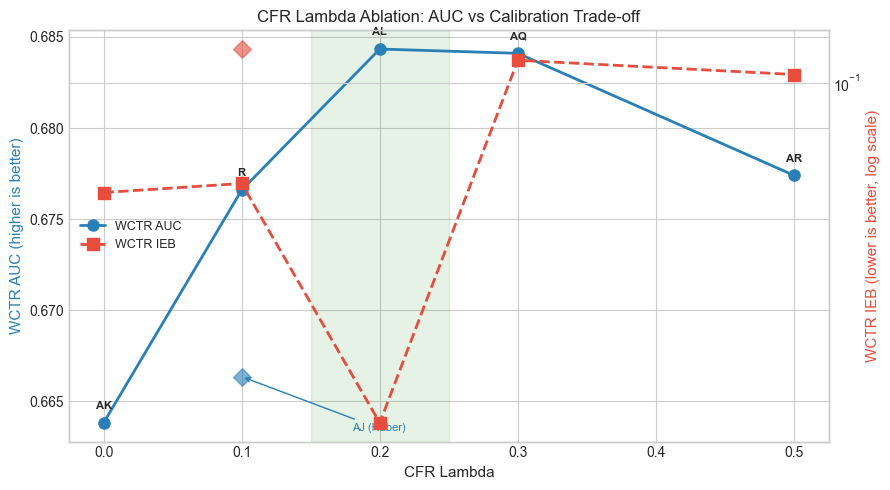

In [6]:
# CFR Lambda Ablation: AUC vs IEB trade-off
cfr_data = pd.DataFrame([
    dict(cfr_lambda=0.0, Run='AK', WCTR_AUC=results['AK']['test_wctr_auc'],
         WCTR_IEB=results['AK']['test_wctr_ieb'], CTR_AUC=results['AK']['test_ctr_biased_auc']),
    dict(cfr_lambda=0.1, Run='R',  WCTR_AUC=0.6766, WCTR_IEB=0.056, CTR_AUC=0.5526),
    dict(cfr_lambda=0.2, Run='AL', WCTR_AUC=results['AL']['test_wctr_auc'],
         WCTR_IEB=results['AL']['test_wctr_ieb'], CTR_AUC=results['AL']['test_ctr_biased_auc']),
    dict(cfr_lambda=0.3, Run='AQ', WCTR_AUC=0.6841, WCTR_IEB=0.114, CTR_AUC=0.5407),
    dict(cfr_lambda=0.5, Run='AR', WCTR_AUC=0.6774, WCTR_IEB=0.105, CTR_AUC=0.5489),
])

# Also add AJ (cfr=0.1 + Huber) as a separate point
aj_point = dict(cfr_lambda=0.1, Run='AJ',
                WCTR_AUC=results['AJ']['test_wctr_auc'],
                WCTR_IEB=results['AJ']['test_wctr_ieb'],
                CTR_AUC=results['AJ']['test_ctr_biased_auc'])

print('CFR Lambda Ablation Results:')
display(cfr_data.style.format({
    'WCTR_AUC': '{:.4f}', 'WCTR_IEB': '{:.3f}', 'CTR_AUC': '{:.4f}',
}).set_caption('MSE imputation loss (main line)'))
print(f'\nConfound: Run AJ (cfr=0.1 + Huber loss): '
      f'WCTR AUC={aj_point["WCTR_AUC"]:.4f}, IEB={aj_point["WCTR_IEB"]:.3f}')

# Dual-axis line plot
fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

# Left axis: WCTR AUC
line1, = ax1.plot(cfr_data['cfr_lambda'], cfr_data['WCTR_AUC'],
                  'o-', color='#2980b9', linewidth=2, markersize=8, label='WCTR AUC')
ax1.scatter([aj_point['cfr_lambda']], [aj_point['WCTR_AUC']],
            marker='D', color='#2980b9', s=80, zorder=5, alpha=0.6)
ax1.annotate('AJ (Huber)', xy=(0.1, aj_point['WCTR_AUC']),
             xytext=(0.18, aj_point['WCTR_AUC'] - 0.003),
             fontsize=8, color='#2980b9', arrowprops=dict(arrowstyle='->', color='#2980b9'))

# Right axis: WCTR IEB (log scale)
line2, = ax2.plot(cfr_data['cfr_lambda'], cfr_data['WCTR_IEB'],
                  's--', color='#e74c3c', linewidth=2, markersize=8, label='WCTR IEB')
ax2.scatter([aj_point['cfr_lambda']], [aj_point['WCTR_IEB']],
            marker='D', color='#e74c3c', s=80, zorder=5, alpha=0.6)
ax2.set_yscale('log')

# Annotate run IDs
for _, row in cfr_data.iterrows():
    ax1.annotate(row['Run'], xy=(row['cfr_lambda'], row['WCTR_AUC']),
                 xytext=(0, 10), textcoords='offset points',
                 fontsize=8, ha='center', fontweight='bold')

# Highlight sweet spot
ax1.axvspan(0.15, 0.25, alpha=0.1, color='green', label='Sweet spot (cfr=0.2)')

ax1.set_xlabel('CFR Lambda', fontsize=11)
ax1.set_ylabel('WCTR AUC (higher is better)', fontsize=11, color='#2980b9')
ax2.set_ylabel('WCTR IEB (lower is better, log scale)', fontsize=11, color='#e74c3c')
ax1.set_title('CFR Lambda Ablation: AUC vs Calibration Trade-off', fontsize=12)

lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center left', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_PATH / '04_cfr_lambda_ablation.png', dpi=150, bbox_inches='tight')
plt.show()

### CFR Ablation 해석

- **cfr=0.0 (AK)**: CFR 비활성화 → imputation tower가 unselected samples에서 overshoot → noisy DR correction → AUC 0.6638, IEB 0.053
- **cfr=0.1 (R)**: 약한 regularization → AUC 0.6766, IEB 0.056
- **cfr=0.2 (AL)**: **Sweet spot** — imputation overshoot 억제 + 충분한 correction signal 유지 → AUC 0.6843 (peak), IEB 0.014 (best)
- **cfr=0.3 (AQ)**: Over-regularization 시작 → $\hat{\delta} \approx 0$으로 수렴 → IEB 8x 악화 (0.114)
- **cfr=0.5 (AR)**: 강한 over-regularization → 순수 IPW에 근접 → positivity 위반 노출 → IEB 0.105

**AJ (cfr=0.1 + Huber)**: 동일 cfr에서 imputation loss를 Huber로 변경. Win_weight=0.01에서 imputation target noise가 작아 Huber의 robustness 이점 없음. AUC 0.6664 (R 대비 -0.010).

---
## Section 5: Training Dynamics 비교

Run AL (ESCM2-WC DR) vs Run J (ESMM-WC)의 epoch별 loss component 비교.

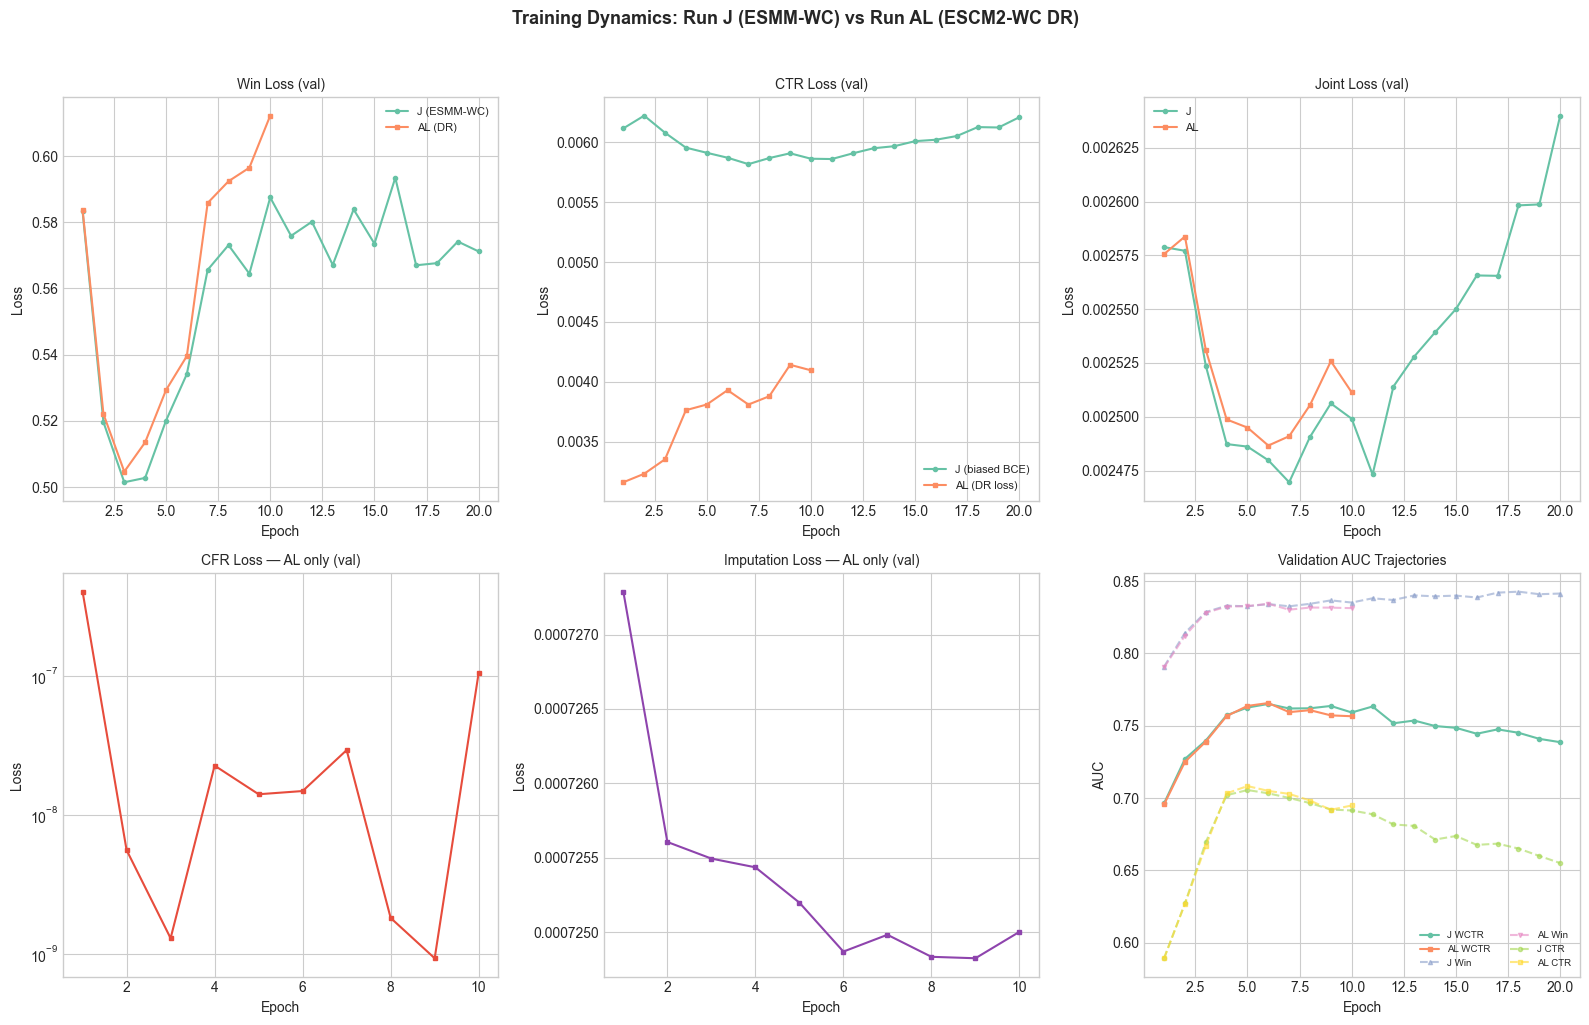

In [7]:
# Training dynamics: Run AL vs Run J
if 'J' in results and 'AL' in results:
    hist_j = pd.DataFrame(results['J']['training_history'])
    hist_al = pd.DataFrame(results['AL']['training_history'])

    fig, axes = plt.subplots(2, 3, figsize=(16, 10))

    # Panel 1: Win Loss
    ax = axes[0, 0]
    ax.plot(hist_j['epoch'], hist_j['val_win'], 'o-', label='J (ESMM-WC)', markersize=3)
    ax.plot(hist_al['epoch'], hist_al['val_win'], 's-', label='AL (DR)', markersize=3)
    ax.set_title('Win Loss (val)', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

    # Panel 2: CTR Loss
    ax = axes[0, 1]
    ax.plot(hist_j['epoch'], hist_j['val_ctr'], 'o-', label='J (biased BCE)', markersize=3)
    ax.plot(hist_al['epoch'], hist_al['val_ctr'], 's-', label='AL (DR loss)', markersize=3)
    ax.set_title('CTR Loss (val)', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

    # Panel 3: Joint Loss
    ax = axes[0, 2]
    ax.plot(hist_j['epoch'], hist_j['val_joint'], 'o-', label='J', markersize=3)
    ax.plot(hist_al['epoch'], hist_al['val_joint'], 's-', label='AL', markersize=3)
    ax.set_title('Joint Loss (val)', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=8)

    # Panel 4: CFR Loss (AL only)
    ax = axes[1, 0]
    if 'val_cfr' in hist_al.columns:
        ax.plot(hist_al['epoch'], hist_al['val_cfr'], 's-', color='#e74c3c', markersize=3)
        ax.set_title('CFR Loss — AL only (val)', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_yscale('log')
    else:
        ax.text(0.5, 0.5, 'CFR data not available', ha='center', va='center',
                transform=ax.transAxes)

    # Panel 5: Imputation Loss (AL only)
    ax = axes[1, 1]
    if 'val_impute' in hist_al.columns:
        ax.plot(hist_al['epoch'], hist_al['val_impute'], 's-', color='#8e44ad', markersize=3)
        ax.set_title('Imputation Loss — AL only (val)', fontsize=10)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
    else:
        ax.text(0.5, 0.5, 'Imputation data not available', ha='center', va='center',
                transform=ax.transAxes)

    # Panel 6: Validation AUC Trajectories
    ax = axes[1, 2]
    ax.plot(hist_j['epoch'], hist_j['wctr_auc'], 'o-', label='J WCTR', markersize=3)
    ax.plot(hist_al['epoch'], hist_al['wctr_auc'], 's-', label='AL WCTR', markersize=3)
    ax.plot(hist_j['epoch'], hist_j['win_auc'], '^--', label='J Win', markersize=3, alpha=0.6)
    ax.plot(hist_al['epoch'], hist_al['win_auc'], 'v--', label='AL Win', markersize=3, alpha=0.6)
    ax.plot(hist_j['epoch'], hist_j['ctr_auc'], 'o--', label='J CTR', markersize=3, alpha=0.6)
    ax.plot(hist_al['epoch'], hist_al['ctr_auc'], 's--', label='AL CTR', markersize=3, alpha=0.6)
    ax.set_title('Validation AUC Trajectories', fontsize=10)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.legend(fontsize=7, ncol=2)

    fig.suptitle('Training Dynamics: Run J (ESMM-WC) vs Run AL (ESCM2-WC DR)',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(FIG_PATH / '04_training_dynamics.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Training history not available for both J and AL.')

---
## Section 6: Debiasing Ablation Ladder

Biased baseline → ESMM-WC → ESCM2-WC(IPW) → ESCM2-WC(DR) → DR+ExtPS 순차적 개선.

Debiasing Ablation Ladder:


,Step,Model,Debiasing,WCTR_AUC,WCTR_IEB
0,1,LGB CTR_all (Biased),None,0.5437,—
1,2,ESMM-WC (Run J),ESMM joint,0.6905,1.335
2,3,ESCM2-WC IPW (Run Q)*,IPW,0.6526,0.046
3,4,ESCM2-WC DR (Run AL),DR,0.6843,0.014
4,5,ESCM2-WC DR+ExtPS (Run AW),DR + Ext PS,0.6882,0.045


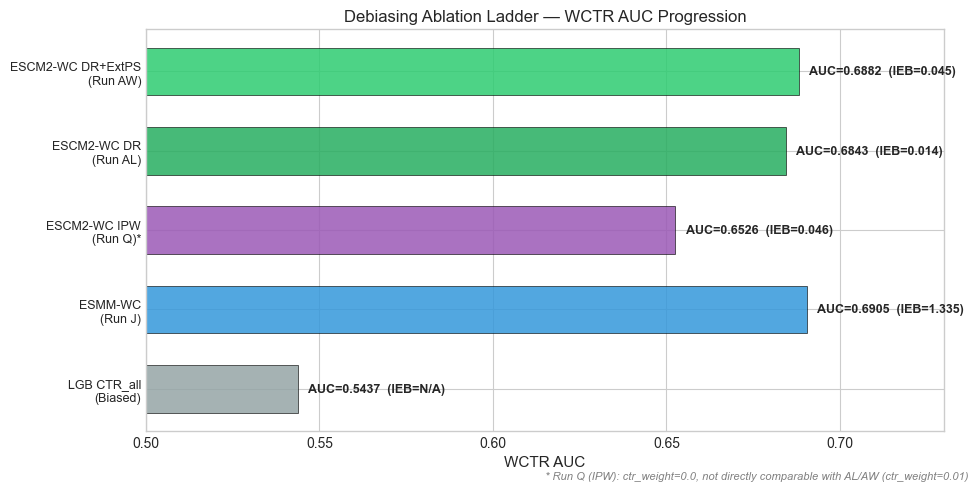

In [8]:
# Debiasing Ablation Ladder
ladder = pd.DataFrame([
    dict(Step=1, Model='LGB CTR_all\n(Biased)', Debiasing='None',
         WCTR_AUC=0.5437, WCTR_IEB=np.nan),
    dict(Step=2, Model='ESMM-WC\n(Run J)', Debiasing='ESMM joint',
         WCTR_AUC=results['J']['test_wctr_auc'], WCTR_IEB=results['J']['test_wctr_ieb']),
    dict(Step=3, Model='ESCM2-WC IPW\n(Run Q)*', Debiasing='IPW',
         WCTR_AUC=0.6526, WCTR_IEB=0.046),
    dict(Step=4, Model='ESCM2-WC DR\n(Run AL)', Debiasing='DR',
         WCTR_AUC=results['AL']['test_wctr_auc'], WCTR_IEB=results['AL']['test_wctr_ieb']),
    dict(Step=5, Model='ESCM2-WC DR+ExtPS\n(Run AW)', Debiasing='DR + Ext PS',
         WCTR_AUC=0.6882, WCTR_IEB=0.045),
])

print('Debiasing Ablation Ladder:')
display(ladder.style.format({
    'WCTR_AUC': '{:.4f}',
    'WCTR_IEB': lambda x: f'{x:.3f}' if not np.isnan(x) else '—',
}).set_caption('* Run Q uses ctr_weight=0.0; not a fully fair comparison with AL (ctr_weight=0.01)'))

# Horizontal grouped bar chart
fig, ax1 = plt.subplots(figsize=(10, 5))
y_pos = np.arange(len(ladder))
colors_auc = ['#95a5a6', '#3498db', '#9b59b6', '#27ae60', '#2ecc71']

bars = ax1.barh(y_pos, ladder['WCTR_AUC'], height=0.6, color=colors_auc,
                edgecolor='black', linewidth=0.5, alpha=0.85)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(ladder['Model'], fontsize=9)
ax1.set_xlabel('WCTR AUC', fontsize=11)
ax1.set_title('Debiasing Ablation Ladder — WCTR AUC Progression', fontsize=12)
ax1.set_xlim(0.5, 0.73)

# Annotate AUC + IEB
for i, (_, row) in enumerate(ladder.iterrows()):
    ieb_text = f'IEB={row["WCTR_IEB"]:.3f}' if not np.isnan(row['WCTR_IEB']) else 'IEB=N/A'
    ax1.text(row['WCTR_AUC'] + 0.003, i,
             f'AUC={row["WCTR_AUC"]:.4f}  ({ieb_text})',
             va='center', fontsize=9, fontweight='bold')

# Caveat
ax1.text(0.5, -0.12, '* Run Q (IPW): ctr_weight=0.0, not directly comparable with AL/AW (ctr_weight=0.01)',
         transform=ax1.transAxes, fontsize=8, style='italic', color='gray')

plt.tight_layout()
plt.savefig(FIG_PATH / '04_debiasing_ablation_ladder.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 7: External PS Impact

**Internal Win Tower** (ESMM-WC/ESCM2-WC 공유):
- Val AUC ~0.83 (strong on validation), Test AUC ~0.64 (temporal shift)
- win_weight=0.01 제약 → propensity quality가 win loss에 의해 제한

**External LGB Win PS**:
- Train AUC 0.93, Val AUC 0.86, Test AUC 0.65
- 별도 학습 → win_weight 제약 없음, but temporal shift (Train→Test AUC 급락)

DR의 importance weight 품질이 External PS로 개선되는가?

External PS Impact:


,Run,Config,PS,WCTR_AUC,WCTR_IEB,CTR_AUC,Win_AUC
0,AL,"cfr=0.2, ctr_w=0.01",Internal,0.6843,0.014,0.5636,0.6403
1,AW,AL + Ext PS,External (LGB),0.6882,0.045,0.5713,0.6466
2,AV,J cfg + Ext PS,External (LGB),0.6712,0.035,0.5604,0.6384


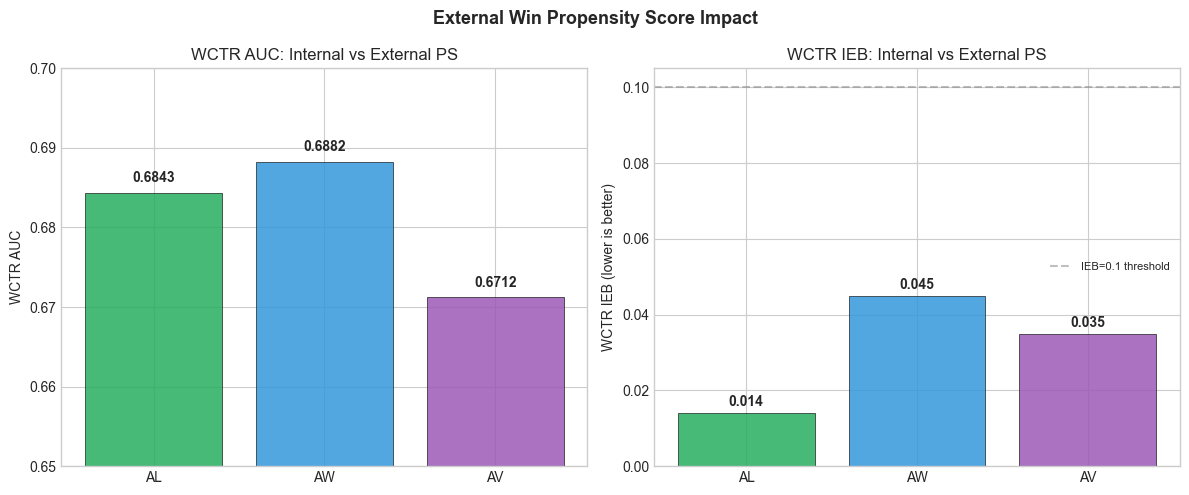

Trade-off: AW achieves +0.004 AUC over AL, but IEB worsens by +0.031
External PS Train AUC(0.93) → Test AUC(0.65) gap causes DR weight inaccuracy at test time.


In [9]:
# External PS Impact: AL (internal) vs AW (external) vs AV (external, ctr_w=0.0)
ps_data = pd.DataFrame([
    dict(Run='AL', Config='cfr=0.2, ctr_w=0.01', PS='Internal',
         WCTR_AUC=results['AL']['test_wctr_auc'],
         WCTR_IEB=results['AL']['test_wctr_ieb'],
         CTR_AUC=results['AL']['test_ctr_biased_auc'],
         Win_AUC=results['AL']['test_win_auc']),
    dict(Run='AW', Config='AL + Ext PS', PS='External (LGB)',
         WCTR_AUC=0.6882, WCTR_IEB=0.045, CTR_AUC=0.5713, Win_AUC=0.6466),
    dict(Run='AV', Config='J cfg + Ext PS', PS='External (LGB)',
         WCTR_AUC=0.6712, WCTR_IEB=0.035, CTR_AUC=0.5604, Win_AUC=0.6384),
])

print('External PS Impact:')
display(ps_data.style.format({
    'WCTR_AUC': '{:.4f}', 'WCTR_IEB': '{:.3f}',
    'CTR_AUC': '{:.4f}', 'Win_AUC': '{:.4f}',
}))

# Bar chart comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(len(ps_data))
colors = ['#27ae60', '#3498db', '#9b59b6']

# WCTR AUC
bars1 = ax1.bar(x, ps_data['WCTR_AUC'], color=colors, edgecolor='black',
                linewidth=0.5, alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(ps_data['Run'], fontsize=10)
ax1.set_ylabel('WCTR AUC')
ax1.set_title('WCTR AUC: Internal vs External PS')
ax1.set_ylim(0.65, 0.70)
for bar, val in zip(bars1, ps_data['WCTR_AUC']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# WCTR IEB
bars2 = ax2.bar(x, ps_data['WCTR_IEB'], color=colors, edgecolor='black',
                linewidth=0.5, alpha=0.85)
ax2.set_xticks(x)
ax2.set_xticklabels(ps_data['Run'], fontsize=10)
ax2.set_ylabel('WCTR IEB (lower is better)')
ax2.set_title('WCTR IEB: Internal vs External PS')
for bar, val in zip(bars2, ps_data['WCTR_IEB']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax2.axhline(y=0.1, color='gray', linestyle='--', alpha=0.5, label='IEB=0.1 threshold')
ax2.legend(fontsize=8)

fig.suptitle('External Win Propensity Score Impact', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / '04_external_ps_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print('Trade-off: AW achieves +0.004 AUC over AL, but IEB worsens by +0.031')
print('External PS Train AUC(0.93) → Test AUC(0.65) gap causes DR weight inaccuracy at test time.')

---
## Section 8: AUC vs Calibration Trade-off

### RTB에서 Calibration이 AUC보다 중요한 이유

Linear bidding strategy:
$$\text{bid}(x) = p_{\text{CTR}}(x) \times \text{base\_price}$$

IEB가 직접 bid error로 전환:
- IEB = $k$ → 평균적으로 $k \times 100\%$ 만큼 과입찰/과소입찰
- AUC는 ranking만 보장; calibration 없이는 절대값 기반 bidding 불가

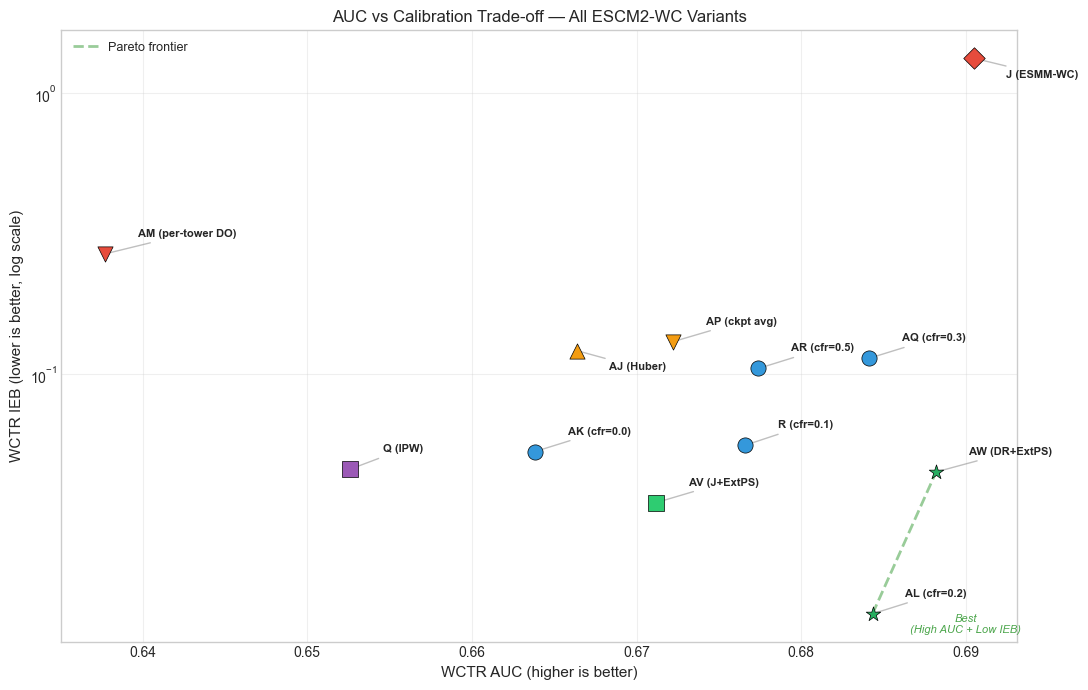

Pareto optimal models:
  Best Calibration: Run AL — WCTR AUC=0.6843, IEB=0.014
  Best AUC:         Run AW — WCTR AUC=0.6882, IEB=0.045


In [10]:
# AUC vs Calibration Scatter Plot — all model variants
scatter_data = pd.DataFrame([
    dict(Run='J (ESMM-WC)', WCTR_AUC=results['J']['test_wctr_auc'],
         WCTR_IEB=results['J']['test_wctr_ieb'], color='#e74c3c', marker='D'),
    dict(Run='AK (cfr=0.0)', WCTR_AUC=results['AK']['test_wctr_auc'],
         WCTR_IEB=results['AK']['test_wctr_ieb'], color='#3498db', marker='o'),
    dict(Run='R (cfr=0.1)', WCTR_AUC=0.6766, WCTR_IEB=0.056,
         color='#3498db', marker='o'),
    dict(Run='AL (cfr=0.2)', WCTR_AUC=results['AL']['test_wctr_auc'],
         WCTR_IEB=results['AL']['test_wctr_ieb'], color='#27ae60', marker='*'),
    dict(Run='AQ (cfr=0.3)', WCTR_AUC=0.6841, WCTR_IEB=0.114,
         color='#3498db', marker='o'),
    dict(Run='AR (cfr=0.5)', WCTR_AUC=0.6774, WCTR_IEB=0.105,
         color='#3498db', marker='o'),
    dict(Run='AJ (Huber)', WCTR_AUC=results['AJ']['test_wctr_auc'],
         WCTR_IEB=results['AJ']['test_wctr_ieb'], color='#f39c12', marker='^'),
    dict(Run='AM (per-tower DO)', WCTR_AUC=results['AM']['test_wctr_auc'],
         WCTR_IEB=results['AM']['test_wctr_ieb'], color='#e74c3c', marker='v'),
    dict(Run='AP (ckpt avg)', WCTR_AUC=results['AP']['test_wctr_auc'],
         WCTR_IEB=results['AP']['test_wctr_ieb'], color='#f39c12', marker='v'),
    dict(Run='Q (IPW)', WCTR_AUC=0.6526, WCTR_IEB=0.046,
         color='#9b59b6', marker='s'),
    dict(Run='AW (DR+ExtPS)', WCTR_AUC=0.6882, WCTR_IEB=0.045,
         color='#27ae60', marker='*'),
    dict(Run='AV (J+ExtPS)', WCTR_AUC=0.6712, WCTR_IEB=0.035,
         color='#2ecc71', marker='s'),
])

fig, ax = plt.subplots(figsize=(11, 7))

for _, row in scatter_data.iterrows():
    ax.scatter(row['WCTR_AUC'], row['WCTR_IEB'],
               c=row['color'], marker=row['marker'], s=120, edgecolors='black',
               linewidth=0.5, zorder=5)
    # Label offset to avoid overlap
    offset_x, offset_y = 0.002, 1.15
    if 'J ' in row['Run']:
        offset_y = 0.85  # Below for J (high IEB)
    ax.annotate(row['Run'], xy=(row['WCTR_AUC'], row['WCTR_IEB']),
                xytext=(row['WCTR_AUC'] + offset_x, row['WCTR_IEB'] * offset_y),
                fontsize=8, fontweight='bold',
                arrowprops=dict(arrowstyle='-', color='gray', alpha=0.5))

# Pareto frontier highlight
pareto_runs = scatter_data[scatter_data['Run'].isin(['AL (cfr=0.2)', 'AW (DR+ExtPS)'])]
ax.plot(pareto_runs['WCTR_AUC'], pareto_runs['WCTR_IEB'],
        'g--', linewidth=2, alpha=0.4, label='Pareto frontier')

ax.set_xlabel('WCTR AUC (higher is better)', fontsize=11)
ax.set_ylabel('WCTR IEB (lower is better, log scale)', fontsize=11)
ax.set_yscale('log')
ax.set_title('AUC vs Calibration Trade-off — All ESCM2-WC Variants', fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Add quadrant annotations
ax.text(0.69, 0.012, 'Best\n(High AUC + Low IEB)', fontsize=8, color='green',
        ha='center', style='italic', alpha=0.7)

plt.tight_layout()
plt.savefig(FIG_PATH / '04_auc_vs_calibration_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

print('Pareto optimal models:')
print(f'  Best Calibration: Run AL — WCTR AUC={results["AL"]["test_wctr_auc"]:.4f}, IEB={results["AL"]["test_wctr_ieb"]:.3f}')
print(f'  Best AUC:         Run AW — WCTR AUC=0.6882, IEB=0.045')

Overbidding Simulation (n_bids=1,000,000, value_per_click=10,000 CPM):


,Model,IEB,pred_ctr,per_bid_error,total_overbid
0,AL (0.014),0.014,0.000811,0.1120,"112,000"
1,AW (0.045),0.045,0.000836,0.3600,"360,000"
2,R (0.056),0.056,0.000845,0.4480,"448,000"
3,AR (0.105),0.105,0.000884,0.8400,"840,000"
4,AQ (0.114),0.114,0.000891,0.9120,"912,000"
5,J (1.335),1.335,0.001868,10.6800,"10,680,000"


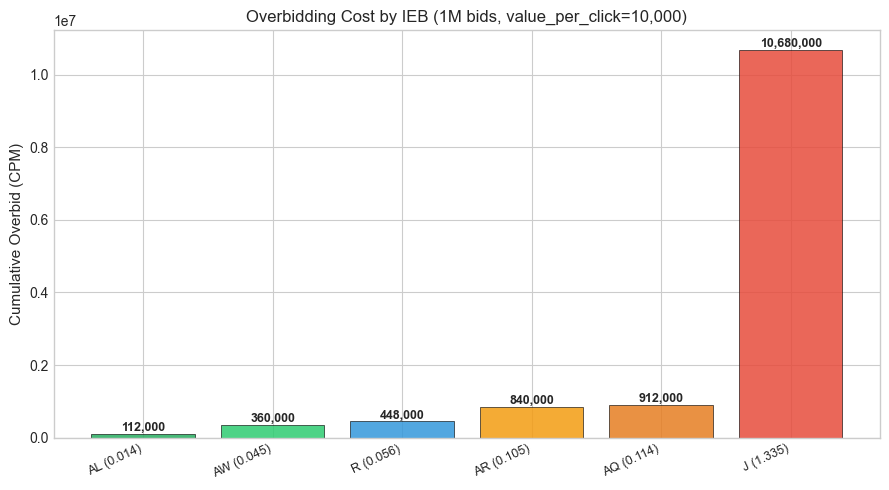


Run J (ESMM-WC) overbids 95x more than Run AL (ESCM2-WC DR).


In [11]:
# Overbidding Simulation: IEB → bid error → cumulative cost
# Assumptions:
#   - Linear bidding: bid(x) = pCTR(x) * value_per_click
#   - value_per_click = 10,000 CPM (= 10 CPM per click at 0.1% CTR)
#   - All-bids CTR ≈ 0.08% (iPinYou: ~23K clicks / 30.6M impressions)
#   - IEB = |E[pCTR] - E[actual_CTR]| / E[actual_CTR]

actual_ctr = 0.0008  # 0.08% all-bids CTR
value_per_click = 10_000  # CPM units
n_bids = 1_000_000

ieb_values = [0.014, 0.045, 0.056, 0.105, 0.114, 1.335]
ieb_labels = ['AL (0.014)', 'AW (0.045)', 'R (0.056)',
              'AR (0.105)', 'AQ (0.114)', 'J (1.335)']

overbid_data = pd.DataFrame([
    dict(
        Model=label,
        IEB=ieb,
        pred_ctr=actual_ctr * (1 + ieb),  # Predicted CTR (overbid case)
        per_bid_error=actual_ctr * ieb * value_per_click,  # CPM per bid
        total_overbid=n_bids * actual_ctr * ieb * value_per_click,  # Total over 1M bids
    )
    for ieb, label in zip(ieb_values, ieb_labels)
])

print(f'Overbidding Simulation (n_bids={n_bids:,}, value_per_click={value_per_click:,} CPM):')
display(overbid_data.style.format({
    'IEB': '{:.3f}', 'pred_ctr': '{:.6f}',
    'per_bid_error': '{:.4f}', 'total_overbid': '{:,.0f}',
}).set_caption('Cumulative overbidding cost (CPM units)'))

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#27ae60', '#2ecc71', '#3498db', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.bar(range(len(overbid_data)), overbid_data['total_overbid'],
              color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_xticks(range(len(overbid_data)))
ax.set_xticklabels(overbid_data['Model'], rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Cumulative Overbid (CPM)', fontsize=11)
ax.set_title(f'Overbidding Cost by IEB (1M bids, value_per_click={value_per_click:,})', fontsize=12)

for bar, val in zip(bars, overbid_data['total_overbid']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIG_PATH / '04_overbidding_simulation.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = overbid_data.iloc[-1]['total_overbid'] / overbid_data.iloc[0]['total_overbid']
print(f'\nRun J (ESMM-WC) overbids {ratio:.0f}x more than Run AL (ESCM2-WC DR).')

---
## Section 9: Negative Results

### 효과 없었던 Ablation 3가지

1. **Per-tower Dropout (Run AM)**: Win/CTR/Impute tower별 별도 dropout → **WCTR AUC -0.047**.
   Win tower의 낮은 dropout(0.2)이 shared embedding을 S2 distribution에 overfit시킴.

2. **Checkpoint Averaging (Run AP)**: top-3 checkpoint weight averaging → **WCTR AUC -0.012**.
   Peak dilution: 최적 epoch 근처의 sub-optimal weights가 혼합되어 성능 저하.

3. **Huber Imputation Loss (Run AJ)**: MSE → Huber(delta=0.1) → **WCTR AUC -0.018**.
   win_weight=0.01에서 imputation target noise가 작아 robustness 이점 없음, quadratic region 축소가 signal 손실.

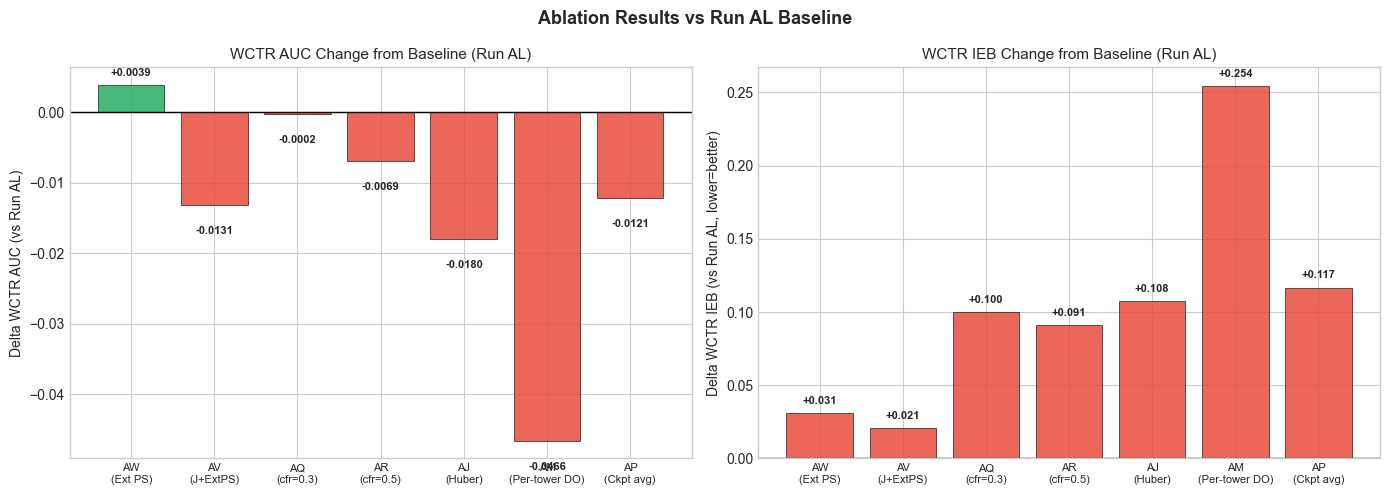

Only Run AW (External PS) improves AUC (+0.004) — all others degrade one or both metrics.


In [12]:
# Negative Results: Delta from Run AL baseline
al_wctr_auc = results['AL']['test_wctr_auc']
al_wctr_ieb = results['AL']['test_wctr_ieb']

delta_data = pd.DataFrame([
    dict(Run='AW\n(Ext PS)', variant='External PS',
         delta_auc=0.6882 - al_wctr_auc,
         delta_ieb=0.045 - al_wctr_ieb),
    dict(Run='AV\n(J+ExtPS)', variant='J cfg + Ext PS',
         delta_auc=0.6712 - al_wctr_auc,
         delta_ieb=0.035 - al_wctr_ieb),
    dict(Run='AQ\n(cfr=0.3)', variant='CFR 0.3',
         delta_auc=0.6841 - al_wctr_auc,
         delta_ieb=0.114 - al_wctr_ieb),
    dict(Run='AR\n(cfr=0.5)', variant='CFR 0.5',
         delta_auc=0.6774 - al_wctr_auc,
         delta_ieb=0.105 - al_wctr_ieb),
    dict(Run='AJ\n(Huber)', variant='Huber imputation',
         delta_auc=results['AJ']['test_wctr_auc'] - al_wctr_auc,
         delta_ieb=results['AJ']['test_wctr_ieb'] - al_wctr_ieb),
    dict(Run='AM\n(Per-tower DO)', variant='Per-tower dropout',
         delta_auc=results['AM']['test_wctr_auc'] - al_wctr_auc,
         delta_ieb=results['AM']['test_wctr_ieb'] - al_wctr_ieb),
    dict(Run='AP\n(Ckpt avg)', variant='Checkpoint averaging',
         delta_auc=results['AP']['test_wctr_auc'] - al_wctr_auc,
         delta_ieb=results['AP']['test_wctr_ieb'] - al_wctr_ieb),
])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Delta AUC bar chart
colors_auc = ['#27ae60' if d > 0 else '#e74c3c' for d in delta_data['delta_auc']]
bars1 = ax1.bar(range(len(delta_data)), delta_data['delta_auc'],
                color=colors_auc, edgecolor='black', linewidth=0.5, alpha=0.85)
ax1.set_xticks(range(len(delta_data)))
ax1.set_xticklabels(delta_data['Run'], fontsize=8)
ax1.axhline(y=0, color='black', linewidth=1)
ax1.set_ylabel('Delta WCTR AUC (vs Run AL)', fontsize=10)
ax1.set_title('WCTR AUC Change from Baseline (Run AL)', fontsize=11)
for bar, val in zip(bars1, delta_data['delta_auc']):
    y_offset = 0.001 if val >= 0 else -0.003
    ax1.text(bar.get_x() + bar.get_width() / 2, val + y_offset,
             f'{val:+.4f}', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=8, fontweight='bold')

# Delta IEB bar chart
colors_ieb = ['#e74c3c' if d > 0 else '#27ae60' for d in delta_data['delta_ieb']]
bars2 = ax2.bar(range(len(delta_data)), delta_data['delta_ieb'],
                color=colors_ieb, edgecolor='black', linewidth=0.5, alpha=0.85)
ax2.set_xticks(range(len(delta_data)))
ax2.set_xticklabels(delta_data['Run'], fontsize=8)
ax2.axhline(y=0, color='black', linewidth=1)
ax2.set_ylabel('Delta WCTR IEB (vs Run AL, lower=better)', fontsize=10)
ax2.set_title('WCTR IEB Change from Baseline (Run AL)', fontsize=11)
for bar, val in zip(bars2, delta_data['delta_ieb']):
    y_offset = 0.005 if val >= 0 else -0.01
    ax2.text(bar.get_x() + bar.get_width() / 2, val + y_offset,
             f'{val:+.3f}', ha='center', va='bottom' if val >= 0 else 'top',
             fontsize=8, fontweight='bold')

fig.suptitle('Ablation Results vs Run AL Baseline', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_PATH / '04_ablation_delta_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print('Only Run AW (External PS) improves AUC (+0.004) — all others degrade one or both metrics.')

---
## Section 10: Summary

### DR 메커니즘 5대 핵심 요약

1. **DR = IPW + Imputation**: Doubly robust — propensity 또는 imputation 중 하나만 올바르면 consistent estimator
2. **CFR Regularization**: cfr_lambda=0.2가 sweet spot. Win=0 영역에서 imputation overshoot 억제
3. **IEB 95x 개선**: ESMM-WC Run J (IEB=1.335) → ESCM2-WC DR Run AL (IEB=0.014)
4. **AUC-Calibration Trade-off**: AUC ranking에서는 ESMM-WC가 우세, calibration에서는 DR이 압도적
5. **External PS**: AUC +0.004 (AW), but IEB +0.031 — temporal shift가 PS 품질 저하

### Component Ablation 결과 요약

| Ablation | Run | Delta WCTR AUC | Delta WCTR IEB | 결론 |
|----------|-----|---------------|---------------|------|
| **External PS** | AW | **+0.004** | +0.031 | AUC 개선, IEB trade-off |
| CFR 0.3 | AQ | -0.000 | +0.100 | Over-regularization |
| CFR 0.5 | AR | -0.007 | +0.091 | Severe over-regularization |
| Huber imputation | AJ | -0.018 | +0.108 | No benefit at low noise |
| Per-tower dropout | AM | -0.047 | +0.254 | Catastrophic: embedding overfit |
| Checkpoint avg | AP | -0.012 | +0.117 | Peak dilution |

### 최종 모델 선택

| 기준 | 추천 모델 | WCTR AUC | WCTR IEB |
|------|----------|----------|----------|
| **Calibration 중시** | Run AL (cfr=0.2, internal PS) | 0.6843 | **0.014** |
| **AUC 중시** | Run AW (AL + External PS) | **0.6882** | 0.045 |

RTB bidding에서는 bid(x) = pCTR(x) * base_price이므로, **calibration (IEB)이 직접 revenue에 영향**.
Production에서는 두 모델의 A/B test로 revenue impact 비교 필요.

### Cross-reference
- **Notebook 03**: 8개 모델 통합 비교 (LGB/LR 6개 + ESMM-WC + ESCM2-WC)
- **Notebook 04 (본 노트북)**: DR 메커니즘 이론 + Component ablation + Negative results
- **docs/performance_tuning.md**: Phase 7-18 전체 실험 기록